In [2]:
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
from snewpy.models.ccsn import Nakazato_2013, Bollig_2016
from snewpy.neutrino import Flavor, MassHierarchy
from snewpy.flavor_transformation import NoTransformation, AdiabaticMSW
import uproot

/home/iakovos-qpix/Programs/Library/MarleyTest/output/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ---------------------------
# File paths (update these to your actual file names)
# ---------------------------
file_paths = [
    #"/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_events.root",
    #"/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_NH_events.root",
   #"/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_IH_events.root",
   "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_events.root",
    "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_NH_events.root",
   "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_IH_events.root",

]

# Labels for legend
labels = [
    #"No Oscillations - Bollig Model",
    #"Normal Hierarchy - Bollig Model",
    #"Inverted Hierarchy - Bollig Model",
    "No Oscillations - Nakazato Model",
    "Normal Hierarchy - Nakazato Model",
    "Inverted Hierarchy - Nakazato Model",
]

# Colors for each dataset
colors = ["blue", "green", "red", "cyan", "magenta", "orange"]

# ---------------------------
# Loop over files and process
# ---------------------------
plt.figure(figsize=(10, 6))

# ---------------------------
# Loop over files and process
# ---------------------------
for path, label, color in zip(file_paths, labels, colors):
    print(f"Processing {label}...")
    file = uproot.open(path)
    tree = file["G4_Photons"]

    # 1. --- Load and Flatten Data ---
    # We use np.hstack because these branches are jagged (one entry per event)
    hx = np.hstack(tree["photon_hit_x"].array(library="np"))
    hy = np.hstack(tree["photon_hit_y"].array(library="np"))
    hz = np.hstack(tree["photon_hit_z"].array(library="np"))
    ht = np.hstack(tree["photon_hit_t"].array(library="np"))

    #print (hx)

    # 2. --- Apply Boundary Masking ---
    # X: 2 < x < 228 | Y: 5 < y < 595 | Z: 3 < z < 338
    mask = (hx > 2) & (hx < 228) & \
           (hy > 5) & (hy < 595)


    mask1 = (hx > 2) & (hx < 228) & \
            (hz > 3) & (hz < 338)
    
    
    clean_x = hx[mask]
    clean_y = hy[mask]
    clean_t = ht[mask] / 1e9  # Convert ns to s

    # 3. --- Plot 1: XY Heatmap (Spatial) ---
    plt.figure(figsize=(10, 7))
    plt.hist2d(clean_x, clean_y, bins=100, cmap='magma', cmin=1)
    plt.colorbar(label='Photon Intensity (Log Scale)')
    plt.xlabel("X Position [cm]")
    plt.ylabel("Y Position [cm]")
    plt.title(f"XY 2D Hit Map")
    plt.grid(alpha=0.2)
    plt.show()

    # 4. --- Plot 2: Photon Arrival Time (Temporal) ---
    plt.figure(figsize=(10, 5))
    # Filter time for unphysical values
    t_mask = (clean_t > 0) & (clean_t < 0.5) 
    
    plt.hist(
        clean_t[t_mask],
        bins=1000,
        color=color,
        alpha=0.7,
        label=label
    )
    plt.xlabel("Photon Arrival Time [s]")
    plt.ylabel("Photon Count")
    plt.title(f"Photon Timing Distribution: {label}")
    plt.xlim(0, 0.5)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


In [ ]:

# ---------------------------
# File paths (update these to your actual file names)
# ---------------------------
file_paths = [
    #"/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_events.root",
    #"/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_NH_events.root",
   #"/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_IH_events.root",
   "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_events.root",
    "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_NH_events.root",
   "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_IH_events.root",

]

# Labels for legend
labels = [
    #"No Oscillations - Bollig Model",
    #"Normal Hierarchy - Bollig Model",
    #"Inverted Hierarchy - Bollig Model",
    "No Oscillations - Nakazato Model",
    "Normal Hierarchy - Nakazato Model",
    "Inverted Hierarchy - Nakazato Model",
]

# Colors for each dataset
colors = ["blue", "green", "red", "cyan", "magenta", "orange"]

# ---------------------------
# Loop over files and process
# ---------------------------
plt.figure(figsize=(10, 6))

for path, label, color in zip(file_paths, labels, colors):
    # Open ROOT file
    file = uproot.open(path)
    tree = file["G4_Photons"]

    # Load photon times
    photon_times = tree["photon_hit_t"].array(library="np")  # jagged list of events

    # Flatten
    all_photon_times = np.hstack(photon_times)

    # Filter unphysical values
    mask = (all_photon_times > 0) & (all_photon_times < 1e10)
    clean_photon_times = all_photon_times[mask]

    # Convert ns → s
    clean_photon_times_s = clean_photon_times / 1e9
    
    print(len(clean_photon_times_s), "photons in", label)

    # Plot histogram
    plt.hist(
    clean_photon_times_s,
    bins=1000000,
    color=color,
    alpha=0.3,  # transparency for overlap
    label=label
    )

# ---------------------------
# Final plot formatting
# ---------------------------
plt.xlabel("Photon Arrival Time [s]")
plt.ylabel("Photon Count")
#plt.xscale("log")  # Uncomment if you want log x-axis
plt.yscale("log")
plt.title("Photon Arrival Time Distribution")
plt.xlim(0, 0.5)  # Adjust as needed
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


182718904 photons in No Oscillations - Nakazato Model


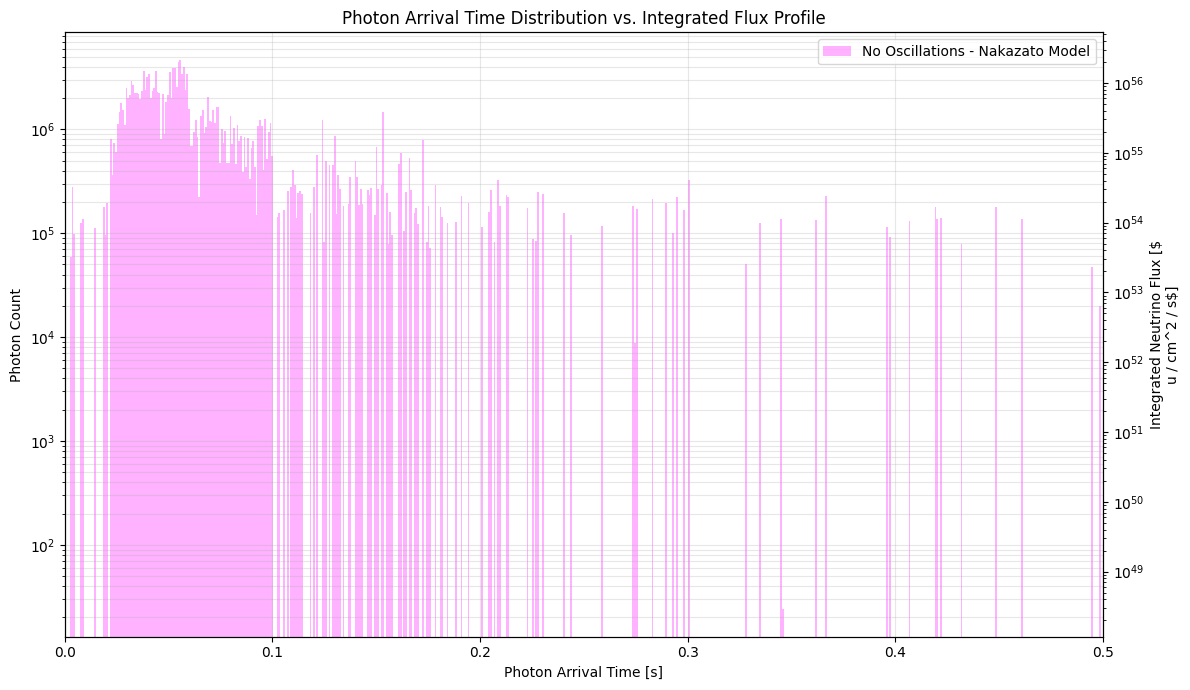

In [ ]:
`# File paths
# ---------------------------
file_paths = [
   "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_events.root",
   #"/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_NH_events.root",
   #"/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_IH_events.root",
]

labels = [
    "No Oscillations - Nakazato Model",
    #"Normal Hierarchy - Nakazato Model",
    #"Inverted Hierarchy - Nakazato Model",`
]

colors = ["magenta", "orange", "blue"]

# Hierarchy mapping for the TH2D names in the flux files
# (Assuming names like h2d_Nakazato_NoOsc, etc.)
hierarchy_map = {
    "No Oscillations - Nakazato Model": "h2d_Nakazato_No_Oscillations",
    #"Normal Hierarchy - Nakazato Model": "h2d_Nakazato_Normal_Hierarchy",
    #"Inverted Hierarchy - Nakazato Model": "h2d_Nakazato_Inverted_Hierarchy"
}

# ---------------------------
# Loop over files and process
# ---------------------------
fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx() # Secondary axis for Flux

# Open the flux source file once
flux_file = uproot.open("/home/iakovos-qpix/Programs/Library/MarleyTest/macros/supernova_data_Nakazato.root")

for path, label, color in zip(file_paths, labels, colors):
    # --- 1. Load Simulation Data ---
    file = uproot.open(path)
    tree = file["G4_Photons"]
    photon_times = tree["photon_hit_t"].array(library="np")
    all_photon_times = np.hstack(photon_times)
    mask = (all_photon_times > 0) & (all_photon_times < 1e10)
    clean_photon_times_s = all_photon_times[mask] / 1e9
    
    print(len(clean_photon_times_s), "photons in", label)

    # Plot Simulation Histogram (ax1)
    ax1.hist(
        clean_photon_times_s,
        bins=10000,
        color=color,
        alpha=0.3,
        label=label
    )

    # --- 2. Load TH2D Flux and Integrate (ax2) ---
    h2d_name = hierarchy_map[label]
    h2d = flux_file[h2d_name]
    
    # Get values, energy bins, and time bins from TH2D
    spec_nue = h2d.values()     # Matrix of Flux(E, t)
    E_edges = h2d.axis(0).edges() 
    t_centers = h2d.axis(1).centers()
    
    # Integrate over Energy (axis 0) to get Total Flux vs Time
    # Using np.trapz as you specified
    flux_vs_time = np.trapezoid(spec_nue, x=E_edges[:-1], axis=0)

    # Overlap the Theoretical Flux curve
    ax2.plot(t_centers, flux_vs_time, color=color, linestyle='-', alpha=0.8)

# ---------------------------
# Final plot formatting
# ---------------------------
ax1.set_xlabel("Photon Arrival Time [s]")
ax1.set_ylabel("Photon Count")
ax1.set_yscale("log")
ax1.set_xlim(0, 0.5)

ax2.set_ylabel("Integrated Neutrino Flux [$\nu / cm^2 / s$]")
ax2.set_yscale("log")

ax1.set_title("Photon Arrival Time Distribution vs. Integrated Flux Profile")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

The cell bellow is responsible for graphing single root file. 

In [ ]:

# Assume clean_photon_times_s is your photon arrival data in seconds
bin_width = 1e-3
bins = np.arange(0, clean_photon_times_s.max(), bin_width)
plt.hist(clean_photon_times_s, bins=bins, label="No Oscillations")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Time [s]")
plt.ylabel("Photon Count")
plt.legend()
plt.show()
